# Falconsai NSFW Model Test Notebook

Notebook for testing `Falconsai/nsfw_image_detection` based on the Hugging Face model card usage examples.

Reference: https://huggingface.co/Falconsai/nsfw_image_detection

In [16]:
# If needed, uncomment to install dependencies in this environment
# !pip install -U transformers torch pillow

In [17]:
%pip install -U transformers torch pillow

In [18]:
%pip install matplotlib

In [ ]:
%pip install -U transformers

In [38]:
IMAGE_PATH = Path(r"F:\1_DrawReference\xbd-downloader\example_AnniePre orderStudio- Model Power StudioProduct name- Annie Le_2026-03-30_113000_1420.jpg")  # change this path

In [40]:
from pathlib import Path
from typing import Any, Callable, cast
from PIL import Image

import numpy as np

MODEL_ID = "Falconsai/nsfw_image_detection"

LOCAL_ONNX_MODEL = Path("data/ai/falconsai_nsfw.onnx")
LABELS = ["normal", "nsfw"]

ClassifierFn = Callable[[Image.Image], list[dict[str, Any]]]

def preprocess_for_onnx(image: Image.Image, input_hw: tuple[int, int] = (224, 224)) -> np.ndarray:
    img = image.convert("RGB").resize(input_hw)
    arr = np.asarray(img, dtype=np.float32) / 255.0
    arr = np.transpose(arr, (2, 0, 1))
    return np.expand_dims(arr, axis=0).astype(np.float32)

def build_huggingface_classifier(model_id: str) -> ClassifierFn:
    from transformers import pipeline

    hf_pipeline = pipeline("image-classification", model=model_id)

    def classify(image: Image.Image) -> list[dict[str, Any]]:
        return cast(list[dict[str, Any]], hf_pipeline(image))

    return classify

def build_onnx_classifier(model_path: Path) -> ClassifierFn:
    import onnxruntime as ort

    if not model_path.exists():
        raise FileNotFoundError(f"ONNX model not found: {model_path.resolve()}")

    session = ort.InferenceSession(str(model_path))
    input_name = session.get_inputs()[0].name

    def classify(image: Image.Image) -> list[dict[str, Any]]:
        input_tensor = preprocess_for_onnx(image)
        outputs = session.run(None, {input_name: input_tensor})
        logits = np.array(outputs[0], dtype=np.float32).reshape(-1)
        logits = logits - logits.max()
        probabilities = np.exp(logits) / np.exp(logits).sum()
        order = probabilities.argsort()[::-1].tolist()
        return [
            {
                "label": LABELS[i] if i < len(LABELS) else f"class_{i}",
                "score": float(probabilities[i]),
            }
            for i in order
        ]

    return classify

classifier_mode = "huggingface"
try:
    classifier = build_huggingface_classifier(MODEL_ID)
except Exception:
    classifier_mode = "onnx"
    classifier = build_onnx_classifier(LOCAL_ONNX_MODEL)

if not IMAGE_PATH.exists():
    raise FileNotFoundError(f"Image not found: {IMAGE_PATH.resolve()}")

img = Image.open(IMAGE_PATH).convert("RGB")
results = classifier(img)
print(f"Loaded via {classifier_mode}: {MODEL_ID if classifier_mode == 'huggingface' else LOCAL_ONNX_MODEL}")
results

Loaded via onnx: data\ai\falconsai_nsfw.onnx


[{'label': 'normal', 'score': 0.9998476505279541},
 {'label': 'nsfw', 'score': 0.0001522923121228814}]

## Test a single local image
Set IMAGE_PATH to a local image file, then run the cell.

In [30]:
if not IMAGE_PATH.exists():
    raise FileNotFoundError(f"Image not found: {IMAGE_PATH.resolve()}")

img = Image.open(IMAGE_PATH).convert("RGB")
results = classifier(img)
results

[{'label': 'nsfw', 'score': 0.9997525811195374},
 {'label': 'normal', 'score': 0.00024743640096858144}]

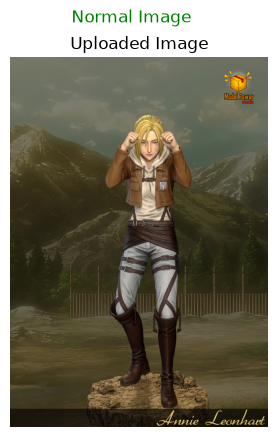

In [41]:
import matplotlib.pyplot as plt
from PIL import Image

# Open the image file
img = Image.open(IMAGE_PATH)

# Display the image
plt.imshow(img)
plt.axis('off') # Hide axes
plt.title('Uploaded Image')
# show image if nsfw or normal
nsfw = any(r["label"] == "nsfw" and r["score"] > 0.5 for r in results)
if nsfw:
    plt.suptitle('NSFW Image', color='red')
else:
    plt.suptitle('Normal Image', color='green')
plt.show()

## Batch test helper
Classify multiple images from a folder and show top result per image.

In [32]:
def classify_folder(folder: Path, pattern: str = "*.jpg"):
    rows = []
    for p in sorted(folder.glob(pattern)):
        img = Image.open(p).convert("RGB")
        pred = classifier(img)
        top = max(pred, key=lambda x: x["score"])
        rows.append({"file": str(p), "label": top["label"], "score": float(top["score"])})
    return rows

FOLDER = Path("data/images")  # change if needed
batch_results = classify_folder(FOLDER, "*.jpg")
batch_results[:10]

[{'file': 'data\\images\\.trashed-1772480589-Screenshot_2026-01-04-00-11-20-425_com.instagram.android.jpg',
  'label': 'normal',
  'score': 0.9915224313735962},
 {'file': 'data\\images\\02ea5cde2aa33ddedfbb89814d92a13f.jpg',
  'label': 'normal',
  'score': 0.9987282156944275},
 {'file': 'data\\images\\0ce0f470b2b0a2dcaa63edffeb681768.jpg',
  'label': 'normal',
  'score': 0.9998229146003723},
 {'file': 'data\\images\\20260213_001416.jpg',
  'label': 'normal',
  'score': 0.9998282194137573},
 {'file': 'data\\images\\4d43092596e9464835805207b4745b4a.jpg',
  'label': 'normal',
  'score': 0.9994938373565674},
 {'file': 'data\\images\\4e4520c78237f3586d79b5d8c9759f17.jpg',
  'label': 'normal',
  'score': 0.9997742772102356},
 {'file': 'data\\images\\7f6970e1a95a78da126656230ec7954b.jpg',
  'label': 'normal',
  'score': 0.9967471361160278},
 {'file': 'data\\images\\__arlecchino_genshin_impact_drawn_by_enipa_28__sample-ce6f83358b9b4506b2bf71c68b1577a4_1.jpg',
  'label': 'nsfw',
  'score': 0.99

## Optional: local ONNX model test
Use the local file `data/ai/falconsai_nsfw.onnx` with `onnxruntime`.
This lets you run classification without downloading from Hugging Face each time.

In [35]:
# If needed, uncomment to install additional deps
# !pip install -U onnxruntime numpy

import numpy as np
import onnxruntime as ort

ONNX_MODEL_PATH = Path("data/ai/falconsai_nsfw.onnx")
LABELS = ["normal", "nsfw"]

if not ONNX_MODEL_PATH.exists():
    raise FileNotFoundError(f"ONNX model not found: {ONNX_MODEL_PATH.resolve()}")

def preprocess_for_onnx(image: Image.Image, input_hw=(224, 224)):
    img = image.convert("RGB").resize(input_hw)
    arr = np.asarray(img, dtype=np.float32) / 255.0
    arr = np.transpose(arr, (2, 0, 1))  # HWC -> CHW
    return np.expand_dims(arr, axis=0).astype(np.float32)

session = ort.InferenceSession(str(ONNX_MODEL_PATH))
input_name = session.get_inputs()[0].name

img = Image.open(IMAGE_PATH).convert("RGB")
input_tensor = preprocess_for_onnx(img, input_hw=(224, 224))
outputs = session.run(None, {input_name: input_tensor})

logits = np.array(outputs[0], dtype=np.float32).reshape(-1)
logits = logits - logits.max()
probabilities = np.exp(logits) / np.exp(logits).sum()
order = probabilities.argsort()[::-1].tolist()

{
    "predictions": [
        {
            "label": LABELS[i] if i < len(LABELS) else f"class_{i}",
            "score": float(probabilities[i]),
        }
        for i in order
    ]
}

{'predictions': [{'label': 'nsfw', 'score': 0.9997525811195374},
  {'label': 'normal', 'score': 0.00024743640096858144}]}